In [1]:
from sklearn.datasets import load_digits
import pandas as pd

digits = load_digits()
df = pd.DataFrame(digits.data, columns=digits.feature_names)
target = pd.Series(digits.target)

print(df.describe())
print(target.value_counts())

       pixel_0_0    pixel_0_1    pixel_0_2    pixel_0_3    pixel_0_4  \
count     1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean         0.0     0.303840     5.204786    11.835838    11.848080   
std          0.0     0.907192     4.754826     4.248842     4.287388   
min          0.0     0.000000     0.000000     0.000000     0.000000   
25%          0.0     0.000000     1.000000    10.000000    10.000000   
50%          0.0     0.000000     4.000000    13.000000    13.000000   
75%          0.0     0.000000     9.000000    15.000000    15.000000   
max          0.0     8.000000    16.000000    16.000000    16.000000   

         pixel_0_5    pixel_0_6    pixel_0_7    pixel_1_0    pixel_1_1  ...  \
count  1797.000000  1797.000000  1797.000000  1797.000000  1797.000000  ...   
mean      5.781859     1.362270     0.129661     0.005565     1.993879  ...   
std       5.666418     3.325775     1.037383     0.094222     3.196160  ...   
min       0.000000     0.000000    

In [2]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df, target, test_size=0.3, stratify=target, random_state=42)

In [3]:
import optuna 
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    
    kernel =  trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly', 'sigmoid'])
    #kernel =  trial.suggest_categorical('kernel', ['sigmoid'])
    C = trial.suggest_float('C', 0.01, 100, log=True)
    gamma = trial.suggest_float('gamma', 0.0001, 1, log=True)
    random_state = trial.suggest_categorical('random_state', [42])

    # default
    degree = 3
    coef0 = 0.0

    if kernel == 'poly':
        degree = trial.suggest_int('degree', 2, 5)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    elif kernel == 'sigmoid':
        coef0 = trial.suggest_float('coef0', -1.0, 1.0)

    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            degree=degree,
            coef0=coef0,
            class_weight=class_weight,
            random_state=random_state
        )
    )

    return cross_val_score(model, x_train, y_train, cv=5, scoring='f1_weighted').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200, show_progress_bar=True)
print(study.best_params)

/home/dave/git/CodeAcademy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 81. Best value: 0.989643: 100%|██████████| 200/200 [00:44<00:00,  4.48it/s]

{'kernel': 'poly', 'C': 0.22707087462558168, 'gamma': 0.024873605634004158, 'random_state': 42, 'degree': 3, 'coef0': 0.709883567346314, 'class_weight': 'balanced'}


Accuracy: 0.9907407407407407
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.96      0.98      0.97        55
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        55
           4       1.00      1.00      1.00        54
           5       0.98      0.98      0.98        55
           6       1.00      1.00      1.00        54
           7       0.98      1.00      0.99        54
           8       1.00      0.96      0.98        52
           9       0.98      0.98      0.98        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540



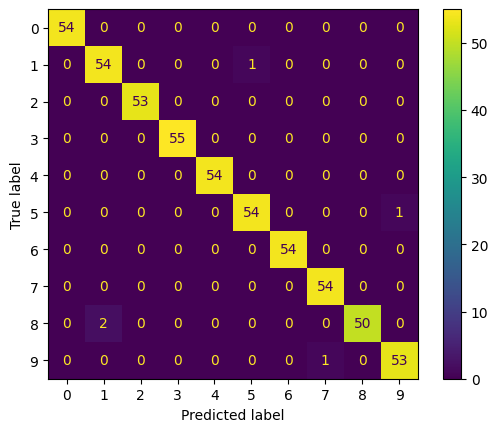

In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

bp = study.best_params

final_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel=bp["kernel"],
        C=bp["C"],
        gamma=bp["gamma"],
        degree=bp.get("degree", 3),
        coef0=bp.get("coef0", 0.0),
        class_weight=bp["class_weight"],
        random_state=bp["random_state"]
    )
)

final_model.fit(x_train, y_train)

y_pred = final_model.predict(x_test)

print("Accuracy:", final_model.score(x_test, y_test))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(final_model, x_test, y_test)